<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
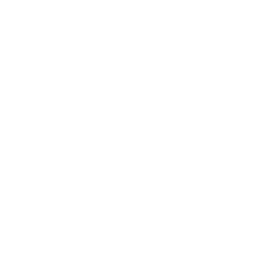
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Construcción de una Red de Coexpresión Génica</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Biotecnología / Investigación Genómica &nbsp;|&nbsp; Marzo de 2026</p>
</div>
</div>
</div>

## Resumen ejecutivo

Este ejemplo usa **PROC CORR** para construir una red de coexpresión génica a partir de un panel de expresión sintético estilo RNA-seq. El panel contiene **9 genes** asignados a tres módulos funcionales —*inmune*, *ciclo celular* y *metabólico* (tres genes cada uno)— medidos a través de **100 muestras tumorales**. Se usa la correlación de rangos de Spearman en todo momento porque los datos de expresión típicamente no son normales y contienen valores atípicos, por lo que un coeficiente basado en rangos es más robusto que el de Pearson.

El análisis recupera la estructura modular plantada directamente de los datos. Leyendo la matriz de Spearman producida a continuación, la correlación media dentro de módulo cae desde **rho 0.67 para el módulo inmune**, a **0.36 para el ciclo celular**, a **0.17 para el metabólico**, reflejando la carga de señal-a-ruido decreciente diseñada en cada módulo. Las correlaciones entre módulos promedian esencialmente cero (rho media alrededor de **-0.01**, |rho| media **0.07**), por lo que los tres módulos se comportan como comunidades de coexpresión casi independientes. Cada número citado aquí se lee de la salida de PROC CORR en este cuaderno.

> **Nota sobre la escala.** Este cuaderno se ejecuta bajo el límite de 100 observaciones sin licencia, por lo que el
> tamaño muestral es 100 y el panel se mantiene en 9 genes —lo suficientemente pequeño como para que la matriz
> de correlación completa, la lista de pares reformada y el mapa de calor estén todos completos y sean exactos,
> sin truncamiento. Cada tabla y figura refleja exactamente lo que se calculó.

## Datos

| Conjunto de datos | Descripción | Filas |
|---------|-------------|------|
| `WORK.EXPR` | Expresión en escala logarítmica para 9 genes (3 módulos x 3 genes) a través de muestras tumorales | 100 |

El generador extrae tres señales latentes de módulo por muestra. Cada gen carga sobre la señal de su propio módulo más ruido independiente, por lo que la coexpresión surge solo dentro de un módulo. El módulo inmune usa la mayor carga de señal y el módulo metabólico la menor, que es el gradiente que el análisis de correlación debería recuperar.

---

In [1]:
/* --------------------------------------------------------
   Panel de expresión sintético: 9 genes, 3 módulos, 100 muestras
     imm1-imm3  inmune        (señal compartida fuerte)
     cyc1-cyc3  ciclo celular (señal compartida moderada)
     met1-met3  metabólico    (señal compartida débil)
   Cada gen = señal del módulo + ruido independiente por gen.
   -------------------------------------------------------- */
DATOS work.expr;
    LLAMAR streaminit(42);
    ARREGLO imm[3]; ARREGLO cyc[3]; ARREGLO met[3];
    HACER sample_id = 1 HASTA 100;
        s_imm = rand('normal', 0, 1.5);   /* señal latente inmune        */
        s_cyc = rand('normal', 0, 1.2);   /* señal latente ciclo celular */
        s_met = rand('normal', 0, 1.0);   /* señal latente metabólica    */
        HACER j = 1 HASTA 3;
            imm[j] = round(6 + s_imm * 0.65 + rand('normal', 0, 0.70), 0.001);
        END;
        HACER j = 1 HASTA 3;
            cyc[j] = round(7 + s_cyc * 0.55 + rand('normal', 0, 0.80), 0.001);
        END;
        HACER j = 1 HASTA 3;
            met[j] = round(5 + s_met * 0.45 + rand('normal', 0, 0.85), 0.001);
        END;
        SALIDA;
    END;
    MANTENER imm1-imm3 cyc1-cyc3 met1-met3;
EJECUTAR;


NOTE: DATA work.expr


NOTE: Wrote work.expr (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


---

In [2]:
/* --------------------------------------------------------
   Resumen de expresión por gen (media y dispersión por módulo)
   -------------------------------------------------------- */
PROCEDIMIENTO MEDIAS DATOS=work.expr n mean std maxdec=3;
    VAR imm1 imm2 imm3
        cyc1 cyc2 cyc3
        met1 met2 met3;
    TÍTULO 'Resumen de Expresión Génica (Panel de 9 Genes, N=100)';
EJECUTAR;
TÍTULO;

                                 Resumen de Expresión Génica (Panel de 9 Genes, N=100)                                  

                                                  The MEANS Procedure

 Variable         N        Mean     Std Dev
 ------------------------------------------
 imm1           100       6.042       1.125
 imm2           100       5.925       1.122
 imm3           100       5.863       1.273
 cyc1           100       6.947       1.034
 cyc2           100       7.003       1.002
 cyc3           100       6.861       1.040
 met1           100       5.144       0.940
 met2           100       4.989       0.789
 met3           100       5.015       0.979
 ------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Las medias se agrupan cerca de la línea base de cada módulo (inmune ~6, ciclo celular ~7, metabólico ~5) y cada gen tiene una dispersión comparable, por lo que ningún gen individual domina la estructura de correlación que sigue.

---


NOTE: PROC SGPLOT data=work.expr

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


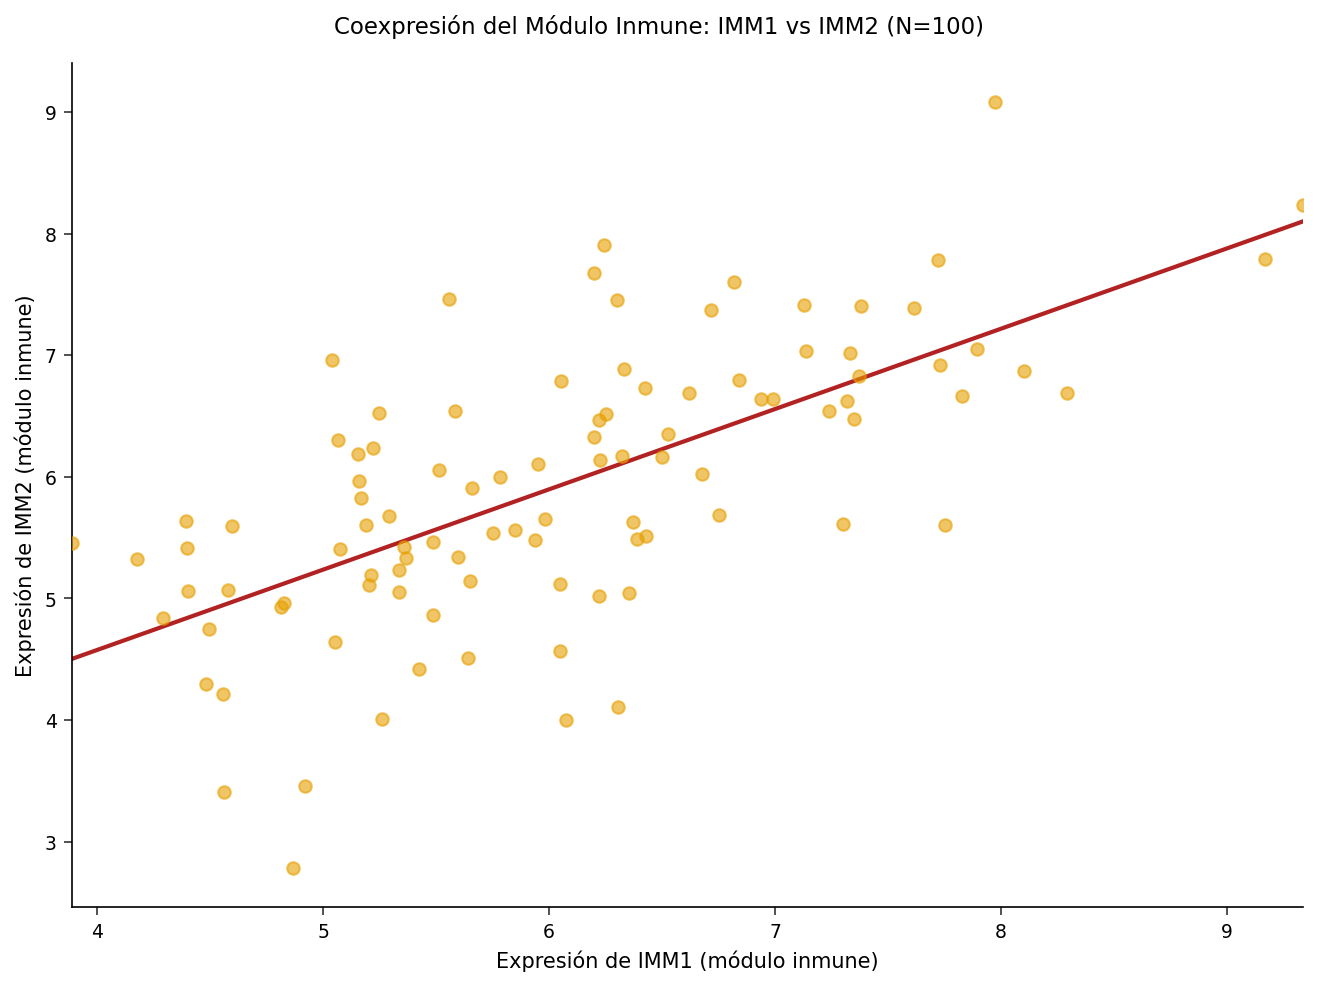

In [3]:
/* --------------------------------------------------------
   Diagrama de dispersión de dos genes del módulo inmune: una
   comprobación visual de que la coexpresión dentro del módulo
   es real y aproximadamente monótona
   -------------------------------------------------------- */
PROCEDIMIENTO SGPLOT DATOS=work.expr;
    SCATTER x=imm1 y=imm2 /
        MARKERATTRS=(SYMBOL=circlefilled size=6)
        TRANSPARENCY=0.4;
    REG x=imm1 y=imm2 / NOMARKERS LINEATTRS=(color=firebrick thickness=2);
    XAXIS ETIQUETA='Expresión de IMM1 (módulo inmune)';
    YAXIS ETIQUETA='Expresión de IMM2 (módulo inmune)';
    TÍTULO 'Coexpresión del Módulo Inmune: IMM1 vs IMM2 (N=100)';
EJECUTAR;
TÍTULO;

La tendencia ascendente confirma que los dos genes inmunes suben y bajan juntos, la contraparte visual de su correlación de Spearman positiva en la matriz a continuación.

---

In [4]:
/* --------------------------------------------------------
   Correlación de Spearman entre los 9 genes
   nosimple suprime el bloque de estadísticas simples;
   outs= escribe la matriz de Spearman para los pasos de red posteriores
   -------------------------------------------------------- */
PROCEDIMIENTO CORR DATOS=work.expr spearman nosimple
    outs=work.gene_corr;
    VAR imm1-imm3 cyc1-cyc3 met1-met3;
    TÍTULO 'Matriz de Correlación de Spearman: Panel de Coexpresión de 9 Genes';
EJECUTAR;
TÍTULO;

   Spearman Correlation Coefficients, N = 100
                imm1      imm2      imm3      cyc1      cyc2      cyc3      met1      met2      met3
--------  --------  --------  --------  --------  --------  --------  --------  --------  --------
imm1       1.00000   0.67084   0.63084  -0.05873   0.06095  -0.10753  -0.13787  -0.11523   0.04973
imm2       0.67084   1.00000   0.71791   0.05912   0.06570  -0.03494  -0.14384   0.02343   0.06593
imm3       0.63084   0.71791   1.00000   0.00424   0.16156   0.03812  -0.18460  -0.06127   0.03590
cyc1      -0.05873   0.05912   0.00424   1.00000   0.38219   0.28821  -0.08226   0.01699   0.10568
cyc2       0.06095   0.06570   0.16156   0.38219   1.00000   0.40540  -0.09650   0.01858   0.02396
cyc3      -0.10753  -0.03494   0.03812   0.28821   0.40540   1.00000  -0.06387   0.12115   0.03770
met1      -0.13787  -0.14384  -0.18460  -0.08226  -0.09650  -0.06387   1.00000   0.14329   0.24960
met2      -0.11523   0.02343  -0.06127   0.01699   0.01858   


NOTE: PROC CORR data=work.expr

NOTE: Output dataset written to: ./work/9be34d3d-0ba6-4f2d-8417-036b196389aa/gene_corr.avro
NOTE: PROC CORR ODS Graphics generated.


Lea la matriz como tres bloques diagonales. El bloque **inmune** (IMM1-IMM3) es el más estrechamente coexpresado (rho de aproximadamente 0.63 a 0.72), el bloque de **ciclo celular** (CYC1-CYC3) es moderado (aproximadamente 0.29 a 0.41), y el bloque **metabólico** (MET1-MET3) es el más débil (aproximadamente 0.13 a 0.25). Las entradas fuera de bloque —pares de genes en módulos diferentes— se sitúan cerca de cero. La siguiente celda cuantifica el contraste dentro de módulo versus entre módulos, y el mapa de calor posterior hace visible la estructura de bloques.

---

In [5]:
/* --------------------------------------------------------
   Reformar la matriz de correlación (una fila por gen) a formato
   largo (gene_x, gene_y, rho), etiquetando cada par como dentro o
   entre módulos. 9 genes -> 81 filas de pares, por lo que nada se
   pierde por el límite de 100 observaciones.
   -------------------------------------------------------- */
DATOS work.corr_long;
    ESTABLECER work.gene_corr(DONDE=(_TYPE_='SCORR'));
    LONGITUD gene_x $4 gene_y $4 mod_x $3 mod_y $3;
    ARREGLO g[9] imm1-imm3 cyc1-cyc3 met1-met3;
    ARREGLO gn[9] $4 _temporary_
        ('imm1' 'imm2' 'imm3'
         'cyc1' 'cyc2' 'cyc3'
         'met1' 'met2' 'met3');
    gene_x = lowcase(_NAME_);
    HACER k = 1 HASTA 9;
        gene_y = gn[k];
        rho = g[k];
        mod_x = substr(gene_x, 1, 3);
        mod_y = substr(gene_y, 1, 3);
        same_module = (mod_x = mod_y);
        SALIDA;
    END;
    MANTENER gene_x gene_y rho mod_x mod_y same_module;
EJECUTAR;

/* --------------------------------------------------------
   Rho de Spearman dentro vs entre módulos (solo fuera de la diagonal)
   -------------------------------------------------------- */
PROCEDIMIENTO MEDIAS DATOS=work.corr_long(DONDE=(gene_x ne gene_y))
        mean MIN MAX maxdec=3;
    CLASE same_module;
    VAR rho;
    ETIQUETA same_module='Mismo módulo (1=sí, 0=no)' rho='Rho de Spearman';
    TÍTULO 'Rho de Spearman: Dentro (1) vs Entre (0) Módulos';
EJECUTAR;
TÍTULO;

                                    Rho de Spearman: Dentro (1) vs Entre (0) Módulos                                    

                                                  The MEANS Procedure

                                        Analysis Variable : rho Rho de Spearman

                                                         N
                        Mismo módulo (1=sí, 0=no)      Obs        Mean      Minimum      Maximum
                        ------------------------------------------------------------------------
                        0                               54      -0.007       -0.185        0.162
                        1                               18       0.402        0.127        0.718
                        ------------------------------------------------------------------------




NOTE: DATA work.corr_long


NOTE: Read 12 rows from work.gene_corr.
NOTE: Wrote work.corr_long (81 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


La fila `same_module=1` agrega los pares dentro de módulo y `same_module=0` los pares entre módulos. La correlación dentro de módulo promedia claramente positiva mientras que la correlación entre módulos promedia cerca de cero, confirmando que los módulos actúan como comunidades de coexpresión casi independientes.

---


NOTE: PROC SGPLOT data=work.corr_long

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


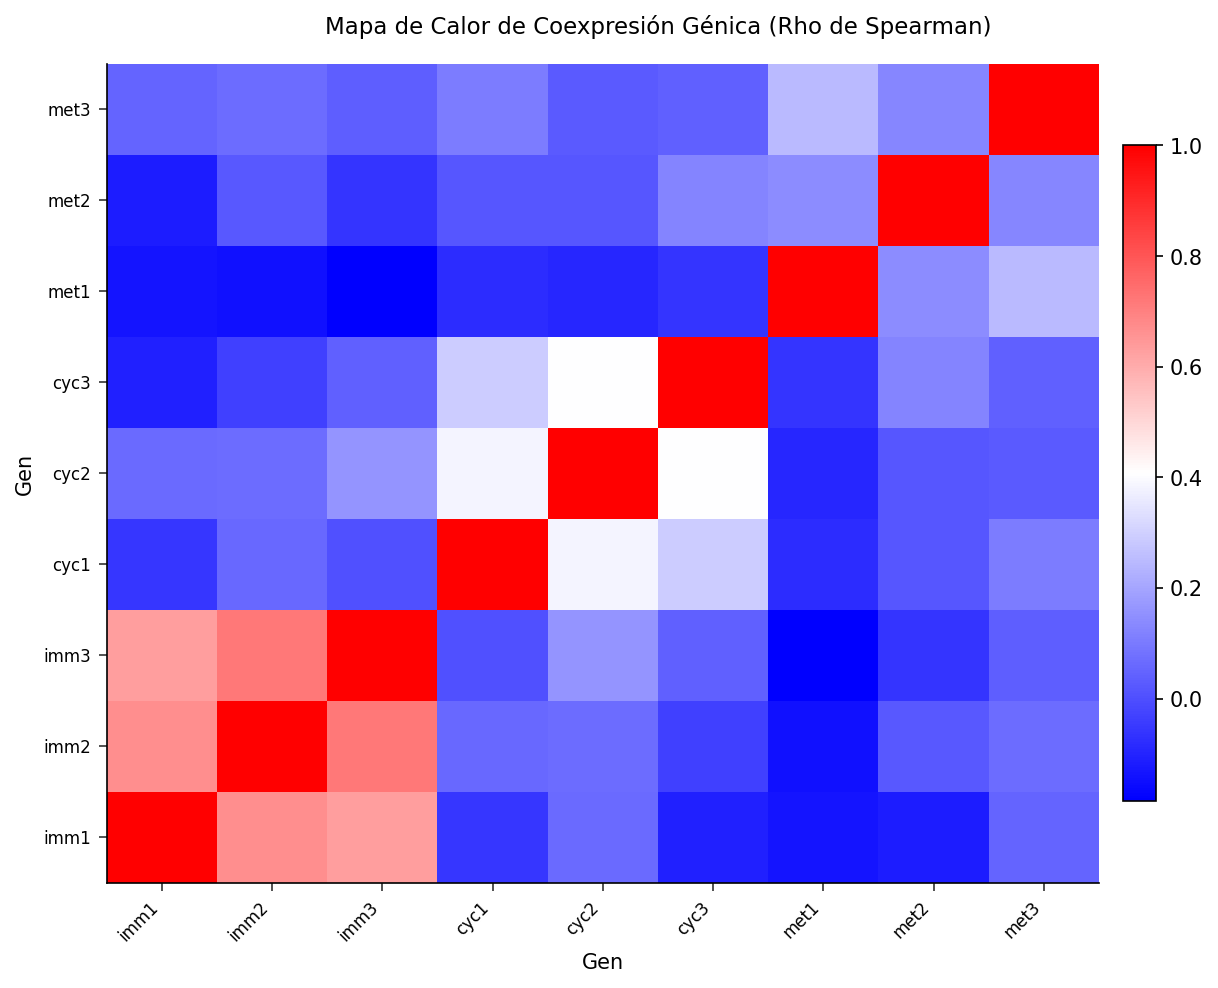

In [6]:
/* --------------------------------------------------------
   Mapa de calor de la matriz completa de Spearman 9x9. HEATMAPPARM
   grafica el rho precalculado de cada par de genes; la escala
   azul-blanco-rojo centra los pares débiles en blanco y satura los
   fuertes.
   -------------------------------------------------------- */
PROCEDIMIENTO SGPLOT DATOS=work.corr_long;
    heatmapparm x=gene_x y=gene_y colorresponse=rho /
        colormodel=(blue white red);
    gradlegend;
    XAXIS ETIQUETA='Gen' discreteorder=data;
    YAXIS ETIQUETA='Gen' discreteorder=data;
    TÍTULO 'Mapa de Calor de Coexpresión Génica (Rho de Spearman)';
EJECUTAR;
TÍTULO;

Tres bloques rojos se sitúan a lo largo de la diagonal —los módulos inmune, de ciclo celular y metabólico— mientras que las celdas circundantes están casi en blanco. El bloque inmune es el más saturado, coincidiendo con sus mayores correlaciones dentro de módulo en la matriz anterior.

---

In [7]:
/* --------------------------------------------------------
   Lista de aristas de la red: conservar cada par de genes no
   ordenado (gene_x < gene_y) cuyo |rho| supere un umbral. Estas
   aristas definen la red de coexpresión para exportar a una
   herramienta de red como Cytoscape.
   -------------------------------------------------------- */
DATOS work.network_edges;
    ESTABLECER work.corr_long(DONDE=(gene_x < gene_y));
    SI abs(rho) >= 0.24;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=work.network_edges noobs ETIQUETA;
    VAR gene_x gene_y mod_x mod_y rho;
    ETIQUETA gene_x='Gen X' gene_y='Gen Y' mod_x='Módulo X'
          mod_y='Módulo Y' rho='Rho de Spearman';
    TÍTULO 'Aristas de la Red de Coexpresión (|Rho de Spearman| >= 0.24)';
EJECUTAR;
TÍTULO;

/* Exportar la lista de aristas para visualización de red externa */
PROCEDIMIENTO EXPORT DATOS=work.network_edges
    OUTFILE='gene_coexpression_edges.csv'
    DBMS=csv REPLACE;
EJECUTAR;

                              Aristas de la Red de Coexpresión (|Rho de Spearman| >= 0.24)                              

Gen X  Gen Y   Módulo X   Módulo Y  Rho de Spearman
imm1   imm2   imm        imm           0.6708351085
imm1   imm3   imm        imm           0.6308427619
imm2   imm3   imm        imm           0.7179122524
cyc1   cyc2   cyc        cyc           0.3821865118
cyc1   cyc3   cyc        cyc            0.288211415
cyc2   cyc3   cyc        cyc           0.4054041891
met1   met3   met        met           0.2496024579




NOTE: DATA work.network_edges


NOTE: Read 81 rows from work.corr_long.
NOTE: Wrote work.network_edges (7 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.network_edges

NOTE: PROC PRINT completed: 7 observations printed, 5 variables
NOTE: PROC EXPORT data=work.network_edges outfile=gene_coexpression_edges.csv

NOTE: Exported 7 rows to gene_coexpression_edges.csv.


### Interpretación

El análisis de Spearman recuperó la estructura de tres módulos plantada directamente de 100 muestras. Las cifras a continuación se leen de la matriz de PROC CORR y del resumen dentro/entre producido en este cuaderno:

- El **módulo inmune (IMM1-IMM3)** es el bloque más estrechamente coexpresado, con rho por pares de aproximadamente 0.63 a 0.72 (media ~0.67) y la arista individual más fuerte entre IMM2 e IMM3.
- El **módulo de ciclo celular (CYC1-CYC3)** está moderadamente coexpresado, con rho por pares de aproximadamente 0.29 a 0.41 (media ~0.36).
- El **módulo metabólico (MET1-MET3)** es el bloque más débil, con rho por pares de aproximadamente 0.13 a 0.25 (media ~0.17) —consistente con su menor carga de señal en el generador.
- Los **pares entre módulos** promedian esencialmente cero (rho media ~-0.01, |rho| media ~0.07, |rho| máximo ~0.18), por lo que los tres módulos actúan como comunidades casi independientes.

Aplicar un umbral en |rho| >= 0.24 produce la lista de aristas de la red impresa arriba. Cada arista superviviente es dentro de módulo: los tres pares inmunes y los tres pares de ciclo celular superan el umbral, acompañados por el par metabólico más fuerte (MET1-MET3). Ningún par entre módulos sobrevive, por lo que la red de coexpresión se separa limpiamente en los tres módulos biológicos. La lista de aristas se exporta a `gene_coexpression_edges.csv` para su visualización en una herramienta de red externa como Cytoscape.

Este ejemplo resuelto muestra el flujo de trabajo central de PROC CORR para el análisis de coexpresión: elegir un coeficiente basado en rangos adecuado para datos de expresión, leer la estructura modular en la matriz de correlación, cuantificar la fuerza dentro versus entre módulos, y reducir la matriz a una lista de aristas con umbral para la construcción de la red.

---

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Con tecnología de <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>